Hilbert space dimension: 65536
Building operators for a 4 x 4 lattice. Please wait.


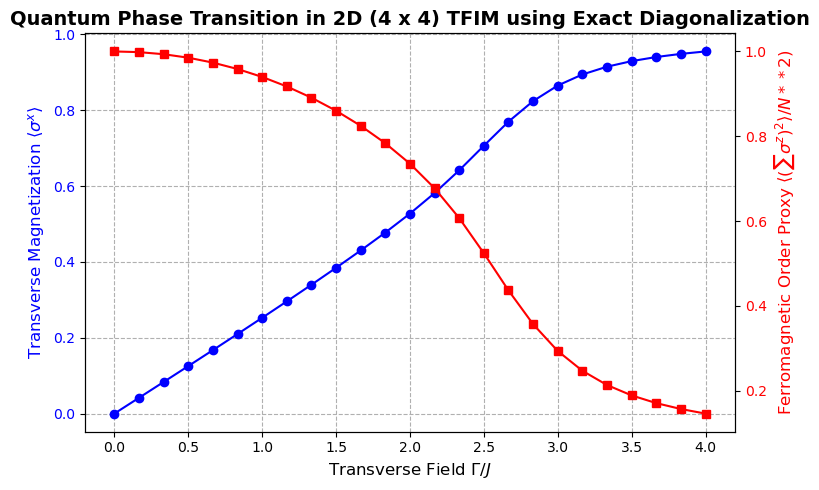

In [2]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# ***System Parameters:***

Lx, Ly = 4, 4 # Lattice dimesnsions
J = 1.0 # Ferromagnetic coupling
gamma = np.linspace(0.0, 4.0, 25) # Transverse field values; use gamma = np.linspace(0.0, 3.0, 25) for clean visual

N = Lx * Ly # Total number of spins

# ***Constructing Pauli Matrices:***

I = sp.eye(2, format = 'csr')
Sx = sp.csr_matrix([[0.0, 1.0],[1.0, 0.0]])
Sz = sp.csr_matrix([[1.0, 0.0], [0.0, -1.0]])

# Embedding a 2 by 2 single-site operator into the complete 2^N Hilbert Space:
def site_op(op, site, N): # To obtain the site operator
  op_list = [I] * N # Creating a list of the matrix elements
  op_list[site] = op # Embedding the operator in question at the desired site in the Kronecker tensor product
  full_op = op_list[0]
  for i in range(1, N):
    full_op = sp.kron(full_op, op_list[i], format = 'csr')
  return full_op

print('Hilbert space dimension:', 2**N)
print(f'Building operators for a {Lx} x {Ly} lattice. Please wait.')

# Pre-computing single-site operators to save memory/time
Sx_dict = {i: site_op(Sx, i, N) for i in range(N)}
Sz_dict = {i: site_op(Sz, i, N) for i in range(N)}
# Using for loop separately causes the error --> matmul: dimension mismatch with signature (n,k=65536),(k=1,m)->(n,m) for H_interact calculation

# *** Building Interaction Term:***

# Implimenting PERIODIC BOUNDARY CONDITIONS to define nearest neighbour on a 2D grid:

H_interact = sp.csr_matrix((2**N, 2**N))

for x in range(Lx):
  for y in range(Ly):
    curr_site = x * Ly + y # Mapping 2D matrix [(x, y)] to 1D list [curr_site]
    # Bottom neighbour:
    down = ((x + 1) % Lx) * Ly + y # Mapping 2D matrix [(x, y)] to 1D list [right]
    #print(down)
    # Right neighbour:
    right = x * Ly + ((y + 1) % Ly)  # Mapping 2D matrix [(x, y)] to 1D list [down]
    #print(right)

    # Left neighbour:
    #left = ((x - 1) % Lx) * Ly + y
    # Up neighbour:
    #up = x * Ly + (y - 1) % Ly
    #left and up is not needed since now our 2D matrix is a 1D list and everything is covered

    H_interact -= J * ((Sz_dict[curr_site] @ Sz_dict[right]) + (Sz_dict[curr_site] @ Sz_dict[down]))

# *** Loop Over Transverse Field Values:***
mag_x_list = []
mag_z_sq_list = []

for g in gamma:
  H_field = sp.csr_matrix((2**N, 2**N))
  for i in range(N):
    H_field -= g * Sx_dict[i]
  H = H_interact + H_field

  # Computing the ground state using Lanczos:
  evals, evecs = spla.eigsh(H, k = 1, which = 'SA')
  ground_state = evecs[ : , 0]

  # Calculating the observables:
  # Transverse magnetization = <Sx> = (1/N) * (sum_i (<ground_state|Sx_i|ground_state>))
  avg_sx = 0.0
  for i in range(N):
    avg_sx += np.vdot(ground_state, Sx_dict[i].dot(ground_state)).real # Imaginary values are unnecessary since expectation values are real
  mag_x_list.append(avg_sx/N) # Creating an array/list out of the transverse magnetization values

  #Ferromagnatic structure factor / Order parameter proxy : (1\N^2) * (<sum_i (Sz^2_i) >)
  total_sz = sp.csr_matrix((2**N, 2**N))
  for i in range(N):
    total_sz += Sz_dict[i]
  sz_sq = np.vdot(ground_state, (total_sz @ total_sz).dot(ground_state)).real # Again, imaginary values are unnecessary since expectation values are real
  mag_z_sq_list.append(sz_sq / (N**2))

# ***Plotting the Phase Transition:***
fig, ax1 = plt.subplots(figsize = (8, 5))
ax1.set_xlabel(r'Transverse Field $\Gamma / J$', fontsize = 12)
ax1.set_ylabel(r'Transverse Magnetization $\langle \sigma^x \rangle$', color = 'b', fontsize = 12)
ax1.plot(gamma, mag_x_list, 'o-', color = 'b')
ax1.tick_params(axis = 'y', labelcolor = 'b')
ax1.grid(True, linestyle = '--')

ax2 = ax1.twinx()
ax2.set_ylabel(r'Ferromagnetic Order Proxy $\langle (\sum \sigma^z)^2 \rangle / N**2)$', color = 'r', fontsize = 12)
ax2.plot(gamma, mag_z_sq_list, 's-', color = 'r')
ax2.tick_params(axis = 'y', labelcolor = 'r')
plt.title(f'Quantum Phase Transition in 2D ({Lx} x {Ly}) TFIM using Exact Diagonalization', fontsize = 14, fontweight = 'bold')

fig.tight_layout()

plt.show()